In [1]:
from IPython.display import Image
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re

# Models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.linear_model import Ridge
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    ExtraTreesClassifier,
    RandomForestRegressor,
    AdaBoostRegressor,
    VotingClassifier,
)
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV , RandomizedSearchCV

# Metrics
from sklearn.metrics import (
    mean_squared_error,
    accuracy_score,
    roc_auc_score,
    roc_curve,
    recall_score,
    confusion_matrix,
    precision_score,
    f1_score,
    classification_report,
    r2_score
)

# Preprocessing
from sklearn.preprocessing import StandardScaler, LabelEncoder , OneHotEncoder , PowerTransformer
from sklearn.impute import SimpleImputer

In [107]:
airbnb = pd.read_csv('AB_NYC_2019.csv')

In [108]:
airbnb.info()

<class 'pandas.DataFrame'>
RangeIndex: 48895 entries, 0 to 48894
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48895 non-null  int64  
 1   name                            48879 non-null  str    
 2   host_id                         48895 non-null  int64  
 3   host_name                       48874 non-null  str    
 4   neighbourhood_group             48895 non-null  str    
 5   neighbourhood                   48895 non-null  str    
 6   latitude                        48895 non-null  float64
 7   longitude                       48895 non-null  float64
 8   room_type                       48895 non-null  str    
 9   price                           48895 non-null  int64  
 10  minimum_nights                  48895 non-null  int64  
 11  number_of_reviews               48895 non-null  int64  
 12  last_review                     38843 non-n

In [109]:
airbnb['average_day_rent'] = airbnb['price'] / airbnb['minimum_nights']

In [110]:
airbnb.dropna(subset=['name'])

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365,average_day_rent
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,2018-10-19,0.21,6,365,149.000000
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,2019-05-21,0.38,2,355,225.000000
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,NaN,NaN,1,365,50.000000
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,2019-07-05,4.64,1,194,89.000000
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,2018-11-19,0.10,1,0,8.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,36484665,Charming one bedroom - newly renovated rowhouse,8232441,Sabrina,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,NaN,NaN,2,9,35.000000
48891,36485057,Affordable room in Bushwick/East Williamsburg,6570630,Marisol,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,NaN,NaN,2,36,10.000000
48892,36485431,Sunny Studio at Historical Neighborhood,23492952,Ilgar & Aysel,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,NaN,NaN,1,27,11.500000
48893,36485609,43rd St. Time Square-cozy single bed,30985759,Taz,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,NaN,NaN,6,2,55.000000


In [111]:
airbnb.drop(['id','host_name','last_review'], axis=1, inplace=True)
airbnb.fillna({'reviews_per_month':0}, inplace=True)

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,average_day_rent
0,Clean & quiet apt home by the park,2787,Brooklyn,Kensington,40.64749,-73.97237,Private room,149,1,9,0.21,6,365,149.000000
1,Skylit Midtown Castle,2845,Manhattan,Midtown,40.75362,-73.98377,Entire home/apt,225,1,45,0.38,2,355,225.000000
2,THE VILLAGE OF HARLEM....NEW YORK !,4632,Manhattan,Harlem,40.80902,-73.94190,Private room,150,3,0,0.00,1,365,50.000000
3,Cozy Entire Floor of Brownstone,4869,Brooklyn,Clinton Hill,40.68514,-73.95976,Entire home/apt,89,1,270,4.64,1,194,89.000000
4,Entire Apt: Spacious Studio/Loft by central park,7192,Manhattan,East Harlem,40.79851,-73.94399,Entire home/apt,80,10,9,0.10,1,0,8.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
48890,Charming one bedroom - newly renovated rowhouse,8232441,Brooklyn,Bedford-Stuyvesant,40.67853,-73.94995,Private room,70,2,0,0.00,2,9,35.000000
48891,Affordable room in Bushwick/East Williamsburg,6570630,Brooklyn,Bushwick,40.70184,-73.93317,Private room,40,4,0,0.00,2,36,10.000000
48892,Sunny Studio at Historical Neighborhood,23492952,Manhattan,Harlem,40.81475,-73.94867,Entire home/apt,115,10,0,0.00,1,27,11.500000
48893,43rd St. Time Square-cozy single bed,30985759,Manhattan,Hell's Kitchen,40.75751,-73.99112,Shared room,55,1,0,0.00,6,2,55.000000


In [112]:
airbnb.describe()

,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,average_day_rent
count,4.889500e+04,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000,48895.000000
mean,6.762001e+07,40.728949,-73.952170,152.720687,7.029962,23.274466,1.090910,7.143982,112.781327,70.174247
std,7.861097e+07,0.054530,0.046157,240.154170,20.510550,44.550582,1.597283,32.952519,131.622289,157.620388
min,2.438000e+03,40.499790,-74.244420,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000
25%,7.822033e+06,40.690100,-73.983070,69.000000,1.000000,1.000000,0.040000,1.000000,0.000000,20.000000
50%,3.079382e+07,40.723070,-73.955680,106.000000,3.000000,5.000000,0.370000,1.000000,45.000000,44.500000
75%,1.074344e+08,40.763115,-73.936275,175.000000,5.000000,24.000000,1.580000,2.000000,227.000000,81.500000
max,2.743213e+08,40.913060,-73.712990,10000.000000,1250.000000,629.000000,58.500000,327.000000,365.000000,8000.000000


In [113]:
airbnb['count'] = 1

### Filtering out all the houses that aren't available the whole year

In [114]:
airbnb = airbnb[airbnb['availability_365'] != 0]

# Filtering all the house prices which are 0

In [115]:
airbnb = airbnb[airbnb['price'] > 0]

# Top 10 Neighbourhoods

In [116]:
top10neighbourhoods = airbnb['neighbourhood'].value_counts().reset_index()[:10]

sns.catplot(
    y='neighbourhood',
    x='count',
    data=top10neighbourhoods,
    kind='bar',
    hue='neighbourhood'
)

# Mean of prices by neighbourhood

In [117]:
# newDf = airbnb[['price','neighbourhood']][airbnb['neighbourhood'].isin(top10neighbourhoods['neighbourhood'])]
# print(newDf)

newDf = airbnb[airbnb['neighbourhood'].isin(top10neighbourhoods['neighbourhood'])].groupby("neighbourhood")["average_day_rent"].mean().reset_index().sort_values(by='average_day_rent',ascending=False)
sns.catplot(
    y='neighbourhood',
    x='average_day_rent',
    kind='bar',
    data=newDf,
)

In [118]:

sns.histplot(
    x='price',
    data=airbnb[airbnb['price'] < 2000],
)

<Axes: xlabel='average_day_rent', ylabel='neighbourhood'>

# Avg day prices by the room type

In [119]:
newDf = airbnb['room_type'].value_counts().reset_index()
sns.barplot(
    y='count',
    x='room_type',
    data=newDf
)
plt.title("Number of occurences of room types")

Text(0.5, 1.0, 'Number of occurences of room types')

In [120]:
newDf = airbnb.groupby("room_type")["average_day_rent"].mean().reset_index().sort_values(by='average_day_rent',ascending=False)
sns.barplot(
    y='average_day_rent',
    x='room_type',
    data=newDf
)
plt.title("Average price for room types")


Text(0.5, 1.0, 'Average price for room types')

In [121]:
sns.boxplot(
    x='average_day_rent',
    y='room_type',
    data=airbnb
)

<Axes: title={'center': 'Average price for room types'}, xlabel='average_day_rent', ylabel='neighbourhood'>

In [122]:
airbnb['average_day_rent'].describe()

count    31354.000000
mean        71.010169
std        166.588334
min          0.079079
25%         18.333333
50%         43.750000
75%         83.333333
max       8000.000000
Name: average_day_rent, dtype: float64

In [123]:
airbnb[airbnb['average_day_rent'] > 2000]

,name,host_id,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,average_day_rent,count
2698,Beautiful 1 Bedroom in Nolita/Soho,213266,Manhattan,Nolita,40.72193,-73.99379,Entire home/apt,5000,1,2,0.03,1,365,5000.0,1
4376,Photography Location,1177497,Brooklyn,Clinton Hill,40.69127,-73.96563,Entire home/apt,4500,1,5,0.09,11,365,4500.0,1
4377,Film Location,1177497,Brooklyn,Clinton Hill,40.69137,-73.96723,Entire home/apt,8000,1,1,0.03,11,365,8000.0,1
6620,SOHO GALLERY,1581845,Manhattan,Tribeca,40.71883,-74.00357,Entire home/apt,2400,1,2,0.05,1,365,2400.0,1
20551,Spectacular Townhouse 4Floor 5BD West Village NYC,101132948,Manhattan,West Village,40.73726,-74.00085,Entire home/apt,2590,1,8,0.41,1,361,2590.0,1
21821,The Otheroom Bar/Event/Filming Space -read det...,18037301,Manhattan,West Village,40.73571,-74.00780,Entire home/apt,4000,1,0,0.00,1,173,4000.0,1
22353,Victorian Film location,2675644,Staten Island,Randall Manor,40.63952,-74.09730,Entire home/apt,5000,1,0,0.00,1,344,5000.0,1
22373,West Chelsea Studios - Penthouse 12,113534805,Manhattan,Chelsea,40.74932,-74.00333,Private room,2800,1,0,0.00,1,89,2800.0,1
22992,"Modern Townhouse for Photo, Film & Daytime Ev...",55017405,Manhattan,Upper West Side,40.77978,-73.97598,Entire home/apt,2900,1,0,0.00,1,180,2900.0,1
28727,The room boom,162116640,Brooklyn,Brighton Beach,40.58363,-73.96405,Private room,3000,1,0,0.00,1,90,3000.0,1


In [124]:
airbnb.info()
len(airbnb)

<class 'pandas.DataFrame'>
Index: 31354 entries, 0 to 48894
Data columns (total 15 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   name                            31350 non-null  str    
 1   host_id                         31354 non-null  int64  
 2   neighbourhood_group             31354 non-null  str    
 3   neighbourhood                   31354 non-null  str    
 4   latitude                        31354 non-null  float64
 5   longitude                       31354 non-null  float64
 6   room_type                       31354 non-null  str    
 7   price                           31354 non-null  int64  
 8   minimum_nights                  31354 non-null  int64  
 9   number_of_reviews               31354 non-null  int64  
 10  reviews_per_month               31354 non-null  float64
 11  calculated_host_listings_count  31354 non-null  int64  
 12  availability_365                31354 non-null  

31354

In [125]:
sub_1 = airbnb.loc[airbnb['neighbourhood'].isin(top10neighbourhoods['neighbourhood'])]
viz_1 = sns.catplot(
    x='neighbourhood',
    hue='neighbourhood_group',
    data=sub_1,
    col='room_type',
    kind='count'
)
viz_1.set_xticklabels(rotation=90)

# Map of Neighbour Hood group

In [126]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=airbnb.longitude,y=airbnb.latitude,hue=airbnb.neighbourhood_group)
plt.ioff()

# map of neighbourhood

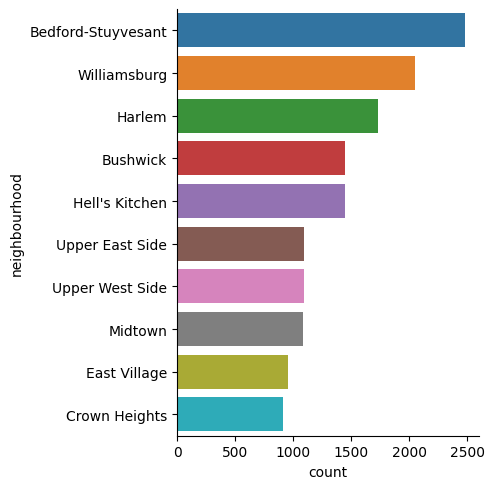

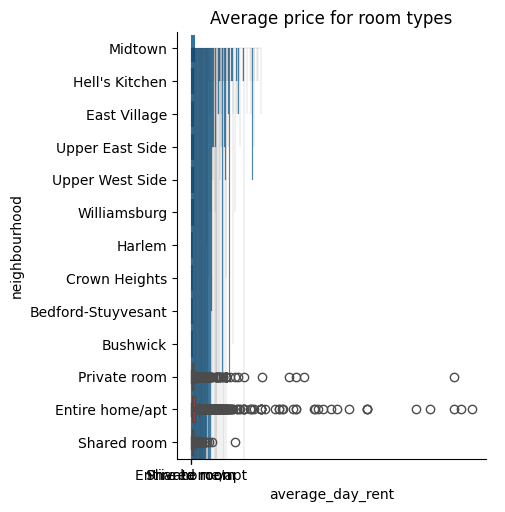

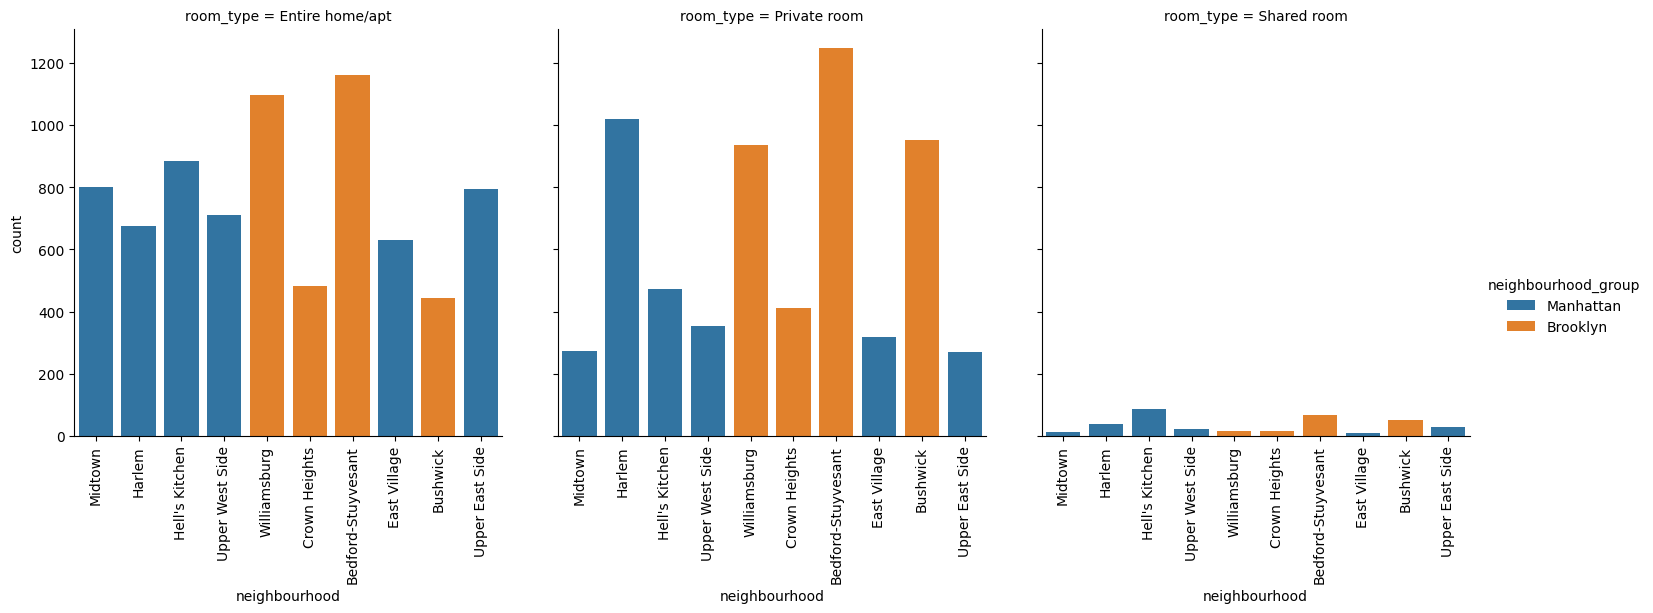

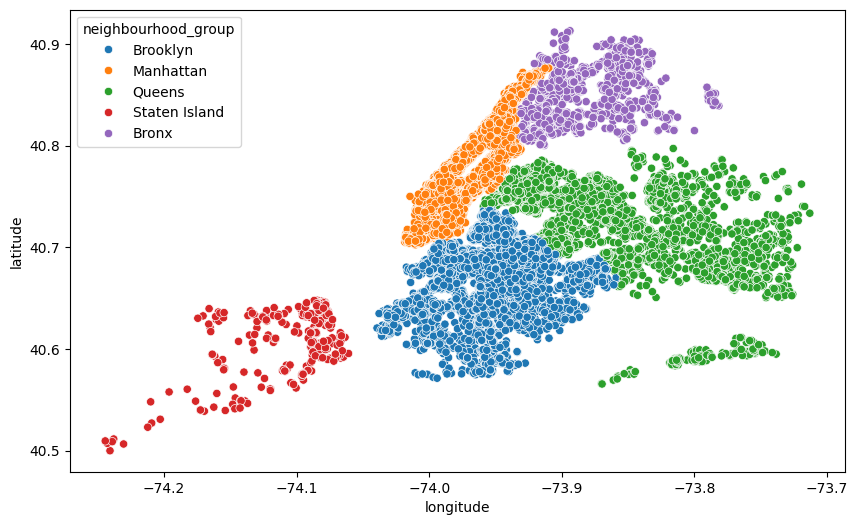

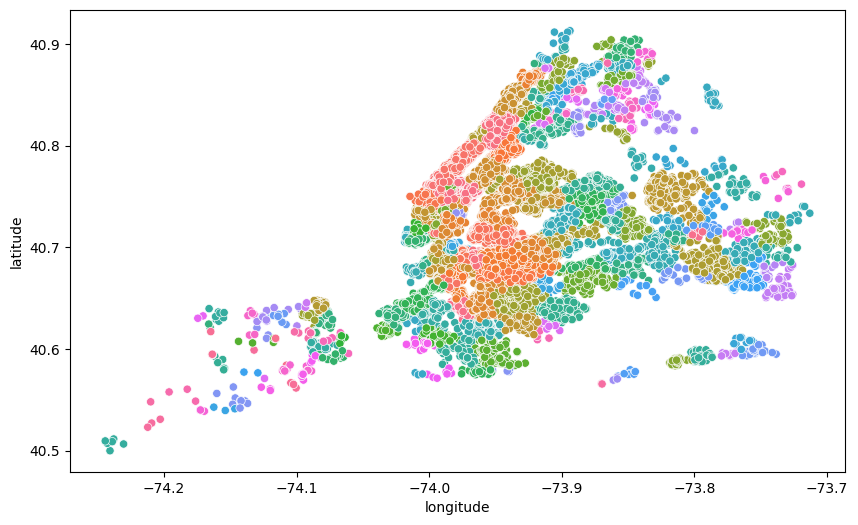

In [127]:
plt.figure(figsize=(10,6))
sns.scatterplot(x=airbnb.longitude,y=airbnb.latitude,hue=airbnb.neighbourhood,legend=False)
plt.show()

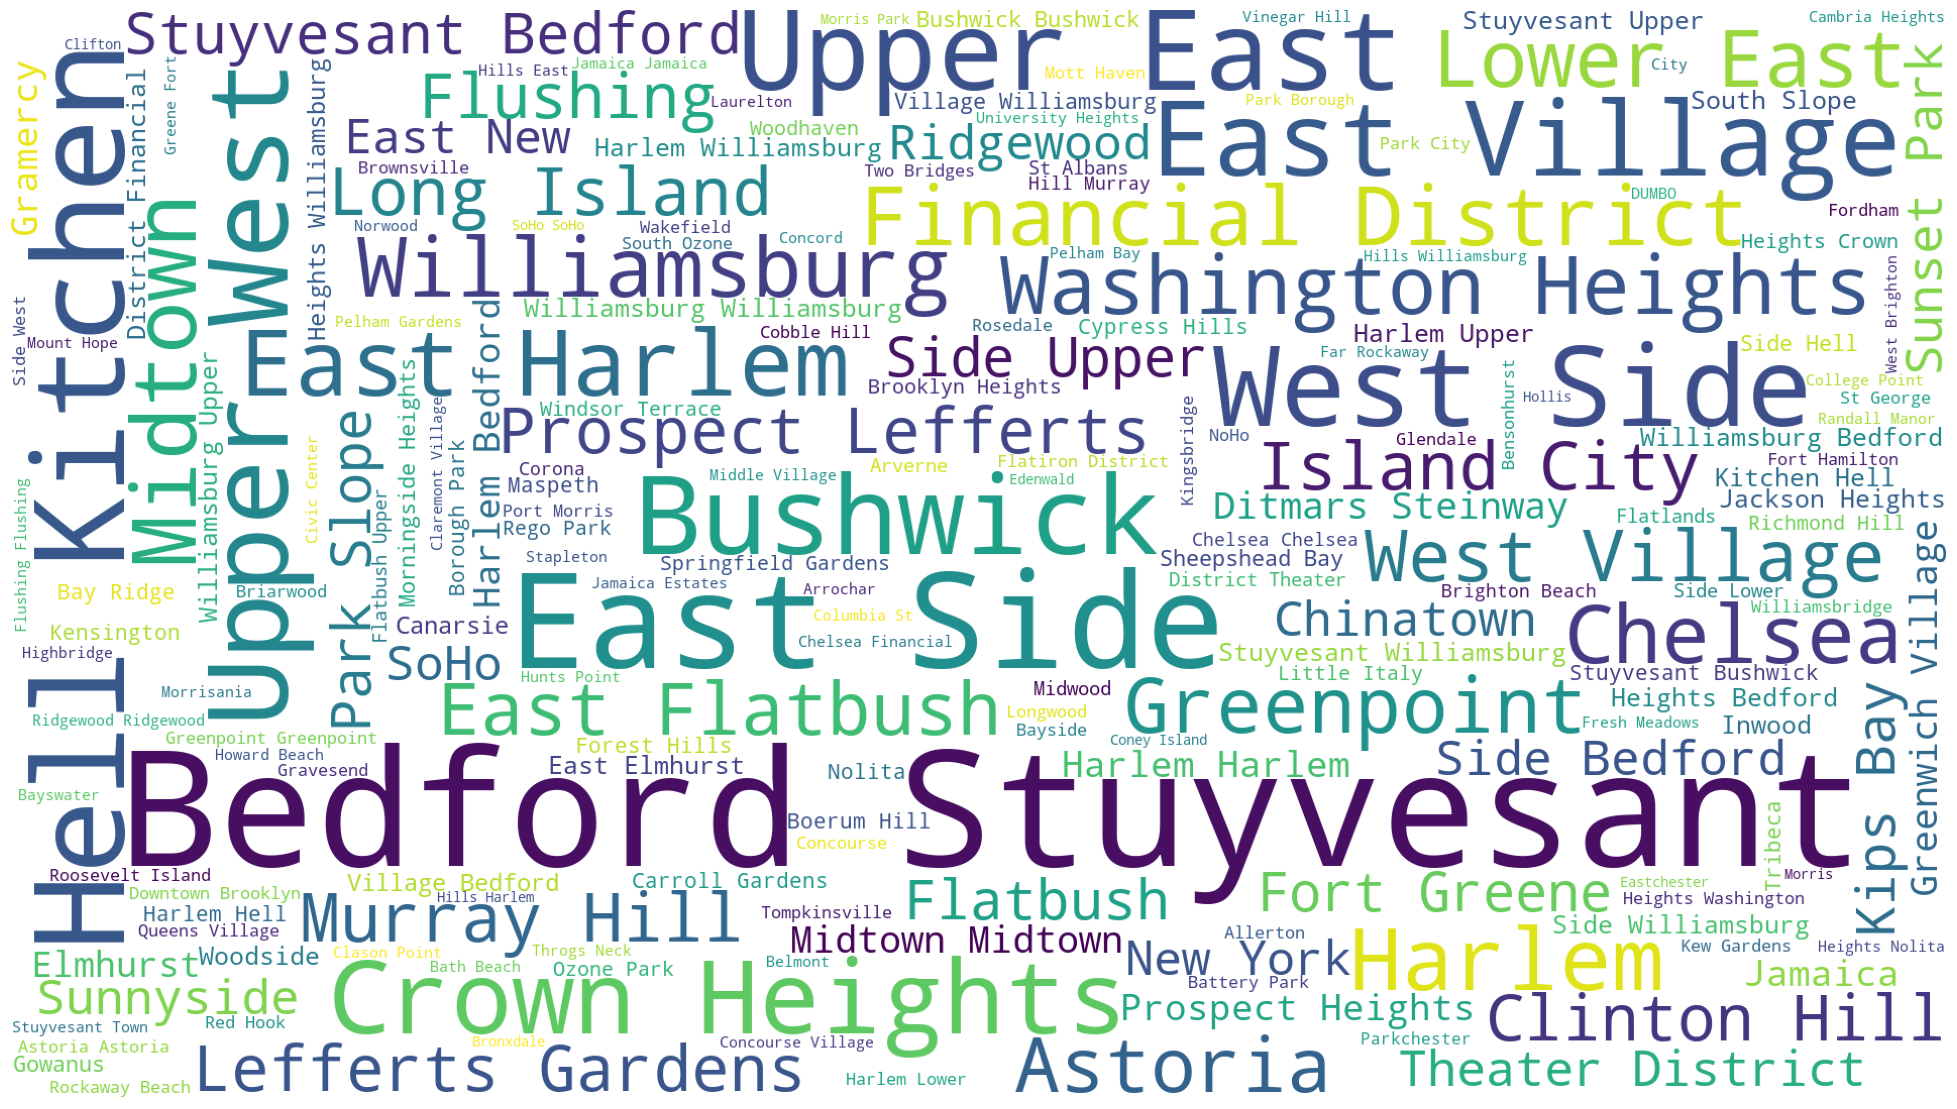

In [128]:
from wordcloud import WordCloud
plt.subplots(figsize=(25,15))
WordCloud(
                          background_color='white',
                          width=1920,
                          height=1080
                         ).generate(" ".join(airbnb.neighbourhood))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [129]:
airbnb.drop(['host_id','latitude','longitude','neighbourhood','number_of_reviews','reviews_per_month','name'], axis=1, inplace=True)
#examing the changes
airbnb.head(5)

,neighbourhood_group,room_type,price,minimum_nights,calculated_host_listings_count,availability_365,average_day_rent,count
0,Brooklyn,Private room,149,1,6,365,149.000000,1
1,Manhattan,Entire home/apt,225,1,2,355,225.000000,1
2,Manhattan,Private room,150,3,1,365,50.000000,1
3,Brooklyn,Entire home/apt,89,1,1,194,89.000000,1
5,Manhattan,Entire home/apt,200,3,1,129,66.666667,1


In [130]:
def Encode(airbnb):
    for column in airbnb.columns[airbnb.columns.isin(['neighbourhood_group', 'room_type'])]:
        airbnb[column] = airbnb[column].factorize()[0]
    return airbnb

airbnb_en = Encode(airbnb.copy())